In [1]:
import pandas as pd

df = pd.read_csv("../data/train_cleaned.csv")
print(df.shape)

(590540, 340)


In [2]:
X = df.drop(columns=['isFraud', 'TransactionID'])
y = df['isFraud']

print(X.shape, y.shape)

(590540, 338) (590540,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())  # should both be ~0.035

(472432, 338) (118108, 338)
0.03498916246147594 0.0349933958749619


In [4]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

baseline_preds = baseline.predict_proba(X_test)[:, 1]  # probability of fraud, not just 0/1

/home/adios123/Documents/projects/FraudDetection/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
from sklearn.metrics import average_precision_score, classification_report

print("Baseline AUC-PR:", average_precision_score(y_test, baseline_preds))
print(classification_report(y_test, baseline.predict(X_test)))

Baseline AUC-PR: 0.06722390070992619
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    113975
           1       0.25      0.00      0.01      4133

    accuracy                           0.96    118108
   macro avg       0.61      0.50      0.49    118108
weighted avg       0.94      0.96      0.95    118108



In [6]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=27,  # tells the model "fraud is 27x rarer, pay more attention to it"
    eval_metric='aucpr',
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict_proba(X_test)[:, 1]

In [7]:
print("XGBoost AUC-PR:", average_precision_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_model.predict(X_test)))

XGBoost AUC-PR: 0.6605557342746635
              precision    recall  f1-score   support

           0       0.99      0.92      0.95    113975
           1       0.26      0.82      0.39      4133

    accuracy                           0.91    118108
   macro avg       0.63      0.87      0.67    118108
weighted avg       0.97      0.91      0.93    118108



<Figure size 1000x800 with 0 Axes>

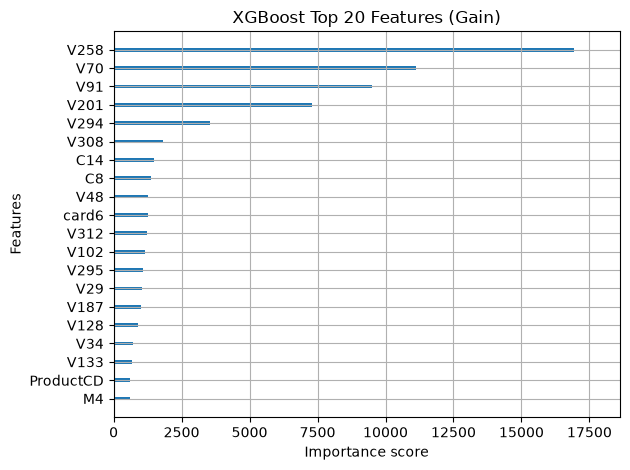


Your engineered 'is_free_email' feature has a Gain score of: 107.58


In [8]:
import matplotlib.pyplot as plt
import xgboost as xgb

plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=20, importance_type='gain', show_values=False)
plt.title('XGBoost Top 20 Features (Gain)')
plt.tight_layout()
plt.show()

booster = xgb_model.get_booster()
importance = booster.get_score(importance_type='gain')

if 'is_free_email' in importance:
    print(f"\nYour engineered 'is_free_email' feature has a Gain score of: {importance['is_free_email']:.2f}")
else:
    print("\nInteresting: 'is_free_email' wasn't used by the trees at all.")

In [9]:
import numpy as np


custom_threshold = 0.85

adjusted_preds = (xgb_preds >= custom_threshold).astype(int)

print(f"--- Results with Threshold = {custom_threshold} ---")
print(classification_report(y_test, adjusted_preds))

--- Results with Threshold = 0.85 ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.72      0.55      0.63      4133

    accuracy                           0.98    118108
   macro avg       0.85      0.77      0.81    118108
weighted avg       0.97      0.98      0.98    118108



In [10]:
import joblib

xgb_model.save_model("../data/fraud_xgboost.json")
print("Saved XGBoost model to JSON.")


Saved XGBoost model to JSON.
